# Project 3: Google Play Store Apps Analysis

# Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load Data

**Load dataset**

In [16]:
df = pd.read_csv('data/googleplaystore.csv')

**Display the First Rows**

In [17]:
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**Check the Shape**

In [18]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (10841, 13)


**Display Dataset Information**

In [19]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


**Check Missing Values**

In [20]:
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

## Check Missing Values in Key Columns

**Check Missing Values in Important Columns**

In [21]:
print("Missing values in key columns:")
print(df[['Rating', 'Installs', 'Genres']].isnull().sum())

Missing values in key columns:
Rating      1474
Installs       0
Genres         0
dtype: int64


**Remove Missing Values**

In [22]:
df = df.dropna(subset=['Rating', 'Installs', 'Genres'])
print(f"Dataset shape after removing missing values: {df.shape}")

Dataset shape after removing missing values: (9367, 13)


**Inspect the Installs Column**

In [23]:
print(df['Installs'].unique()[:10])

<StringArray>
[     '10,000+',     '500,000+',   '5,000,000+',  '50,000,000+',
     '100,000+',      '50,000+',   '1,000,000+',  '10,000,000+',
       '5,000+', '100,000,000+']
Length: 10, dtype: str


**Clean the Installs Column**

In [ ]:
df["Installs"] = df["Installs"].str.replace(r"[+,]", "", regex=True)

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: str

**Convert to Integer**

In [25]:
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [27]:
df = df.dropna(subset=["Installs"])
df['Installs'] = df['Installs'].astype(int)
df["Installs"].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

##  Filter High-Rated Apps

In [28]:
high_rating_apps = df[df['Rating'] > 4.5]
high_rating_apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,10000,Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up
13,Mandala Coloring Book,ART_AND_DESIGN,4.6,4326,21M,100000,Free,0,Everyone,Art & Design,"June 26, 2018",1.0.4,4.4 and up
16,Photo Designer - Write your name with shapes,ART_AND_DESIGN,4.7,3632,5.5M,500000,Free,0,Everyone,Art & Design,"July 31, 2018",3.1,4.1 and up
19,ibis Paint X,ART_AND_DESIGN,4.6,224399,31M,10000000,Free,0,Everyone,Art & Design,"July 30, 2018",5.5.4,4.1 and up


##  Most Popular Genres

In [30]:
genre_installs = high_rating_apps.groupby('Genres')['Installs'].sum().sort_values(ascending=False)
genre_installs.head(10)

Genres
Tools                  2774348850
Action                 1798921250
Communication          1178077520
Productivity           1170622370
Personalization        1135109870
Strategy                938570500
Shopping                807668330
Sports                  718325860
Education;Education     702013010
Photography             688264910
Name: Installs, dtype: int64

##  Visualize Top Genres

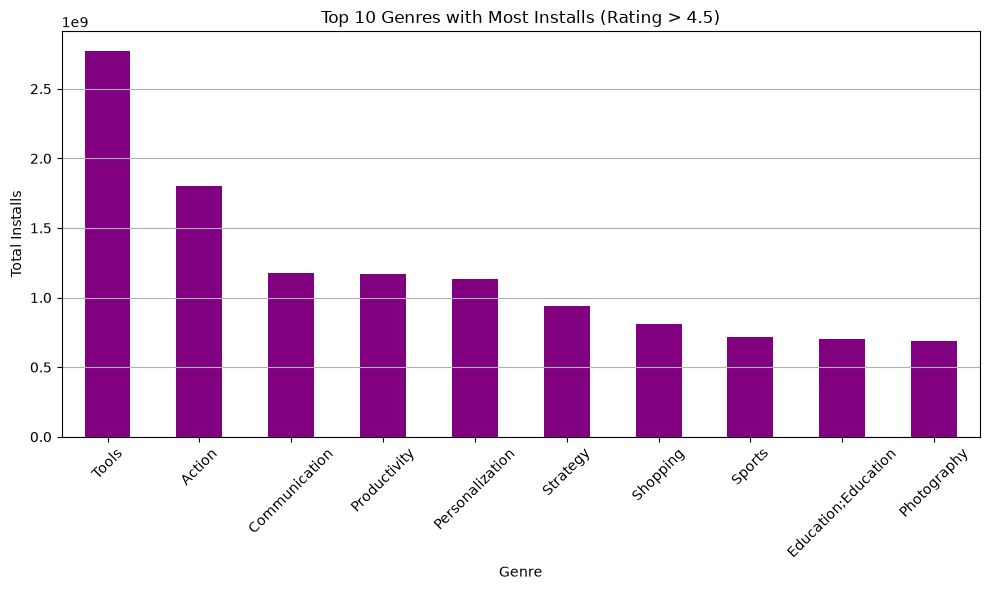

In [32]:
plt.figure(figsize=(10, 6))
genre_installs.head(10).plot(kind='bar', color='purple')
plt.title('Top 10 Genres with Most Installs (Rating > 4.5)')
plt.xlabel('Genre')
plt.ylabel('Total Installs')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
